In [ ]:

# Interexperimental correlation of PRADA reactivity 

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt 

In [ ]:
## 1. Extend Figure 6j --- ---

0.8670041515163104


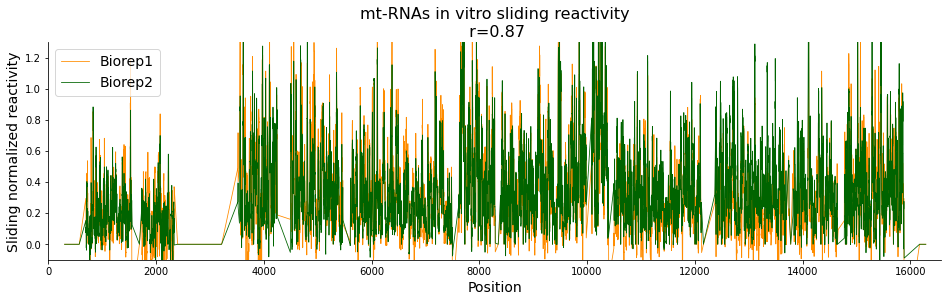

In [4]:
### A. input

rep_1 = pd.read_csv('./Data/PRADA_vitro_4sU_mito_NC_012920.1_profile_rep1.txt',sep='\t')
rep_1 = rep_1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
rep_1['Norm_profile'] = np.where((rep_1['Sequence'] == 'U') | (rep_1['Sequence'] == 'G'), rep_1['Norm_profile'], 0)

rep_2 = pd.read_csv('./Data/PRADA_vitro_4sU_mito_NC_012920.1_profile_rep2.txt',sep='\t')
rep_2 = rep_2[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
rep_2['Norm_profile'] = np.where((rep_2['Sequence'] == 'U') | (rep_2['Sequence'] == 'G'), rep_2['Norm_profile'], 0)

combine = pd.merge(rep_1, rep_2,how ='inner', on =['Nucleotide', 'Nucleotide'])
combine.to_csv("./Data/"+'source_data_Efig6j.csv',sep=',')

### B. ROLLING

roll_vitro = combine['Norm_profile_x'].rolling(10).mean()
roll_vivo = combine['Norm_profile_y'].rolling(10).mean()

tmp1 = pd.DataFrame(roll_vitro)
tmp1.columns = ['slide']
tmp1['group'] = 'vitro'
tmp1['Nucleotide'] = tmp1.index+1

tmp2 = pd.DataFrame(roll_vivo)
tmp2.columns = ['slide']
tmp2['group'] = 'vivo'
tmp2['Nucleotide'] = tmp2.index+1

df = pd.merge(tmp1,tmp2,how='inner',on=['Nucleotide','Nucleotide'])

alldata = pd.merge(df,combine,how='inner',on=['Nucleotide','Nucleotide'])
alldata = alldata.dropna()
stat = stats.pearsonr(alldata.slide_x, alldata.slide_y)
print(stat[0])

### B. Plots correlation

fig, ax = plt.subplots(figsize=(16, 4), sharex=True, sharey=True)
ax.plot(alldata.Nucleotide, alldata.slide_x, linewidth=0.8, color='darkorange',label='Biorep1')  # label="WT (n=%s, %.1d%)" % (flt.shape[0], corr)
ax.plot(alldata.Nucleotide, alldata.slide_y, linewidth=0.8, color='darkgreen',label='Biorep2')
ax.spines[['right', 'top']].set_visible(False) 
plt.legend(loc='best', prop={'size': 14})
ax.set_title('mt-RNAs in vitro sliding reactivity'+ '\n r='+str(round(stat[0],2)),fontsize =16)
ax.set_xlabel("Position",size=14)
ax.set_ylabel("Sliding normalized reactivity",size=14)
ax.set_ylim(-0.1,1.3)
ax.set_xlim(0,16569)
ax.set_ylim()

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig6j_mito_fulllen_bioreps_correlation.pdf',bbox_inches='tight', dpi=300) 